# 🔍 RAG süsteemi vigade analüüs

Selles sülearvutis analüüsime AI Kursuse Nõustaja rakenduse vahesammude logisid.  
Vahesammud on:
1. **Metaandmete filtreerimine** – kasutaja filtrid (semester, linn, EAP jne) rakendatakse andmestikule.
2. **RAGi vektorotsing** – semantiline otsing filteeritud ainete hulgas, tagastab Top 5 vastet.
3. **LLMi vastuse genereerimine** – keelimudel genereerib vastuse leitud konteksti põhjal.

Iga katsetuse tulem (hea/halb) ja halva tulemi korral süüdi olev vahesamm on salvestatud `tagasiside_log.csv` faili.

## 1. Teekide import ja tagasiside logi laadimine

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Lae tagasiside logi
LOG_PATH = "tagasiside_log.csv"

if os.path.isfile(LOG_PATH):
    df_log = pd.read_csv(LOG_PATH)
    print(f"✅ Tagasiside logi laetud: {len(df_log)} rida")
else:
    print("⚠️ tagasiside_log.csv faili ei leitud. Käivita enne rakendust ja anna tagasisidet!")
    df_log = pd.DataFrame()

df_log.head()

✅ Tagasiside logi laetud: 20 rida


,Aeg,Kasutaja päring,Filtrid,Leitud ID-d,Leitud ained,LLM Vastus,Hinnang,Veatüüp
0,2026-02-26 10:01:12,Soovin õppida andmeteadust,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['LTAT.01.001', 'LTAT.02.002', 'LTAT.03.010', ...","['Andmeteaduse alused', 'Masinõpe', 'Andmeanal...",Soovitan järgmisi kursusi: 1) Andmeteaduse alu...,👍 Hea,NaN
1,2026-02-26 10:05:33,Tahan õppida programmeerimist kevadsemestril,"EAP:(0.0, 60.0), Sem:['kevad'], Keel:[], Linn:...","['LTAT.01.003', 'MTAT.03.100', 'LTAT.02.015', ...","['Programmeerimine', 'Algoritmid ja andmestruk...",Siin on kevadsemestri programmeerimise kursuse...,👍 Hea,NaN
2,2026-02-26 10:10:45,Otsin statistika kursusi Narvas,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:['Narva...","['P2NC.00.101', 'P2NC.00.215', 'P2NC.00.302', ...","['Sissejuhatus statistikasse', 'Matemaatika al...",Narva linnas pakutakse statistikaga seotud kur...,👎 Halb,Otsing leidis valed ained (RAG viga)
3,2026-02-26 10:15:21,Soovin õppida keemiat veebiõppes,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...",[],[],Kahjuks ei leidnud ühtegi keemia kursust veebi...,👎 Halb,Filtrid olid liiga karmid/valed
4,2026-02-26 10:20:05,Millised on parimad magistriõppe kursused tehi...,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['MTAT.03.263', 'MTAT.03.292', 'LTAT.01.001', ...","['Tehisintellekt I', 'Süvaõpe', 'Andmeteaduse ...",Magistriõppes on mitmeid suurepäraseid tehisin...,👍 Hea,NaN


## 2. Kõigi logitud tulemuste ülevaade

Kuvame kõik logitud katsetused koos hinnangu ja veatüübiga.

In [2]:
# Üldstatistika
total = len(df_log)
head = len(df_log[df_log["Hinnang"] == "👍 Hea"])
halb = len(df_log[df_log["Hinnang"] == "👎 Halb"])

print(f"📊 Kokku katsetusi: {total}")
print(f"   ✅ Head tulemused: {head} ({head/total*100:.1f}%)")
print(f"   ❌ Halvad tulemused: {halb} ({halb/total*100:.1f}%)")
print()

# Kuva kogu tabel (valitud veerud)
display_cols = ["Aeg", "Kasutaja päring", "Filtrid", "Leitud ained", "Hinnang", "Veatüüp"]
cols_available = [c for c in display_cols if c in df_log.columns]
df_log[cols_available]

📊 Kokku katsetusi: 20
   ✅ Head tulemused: 12 (60.0%)
   ❌ Halvad tulemused: 8 (40.0%)



,Aeg,Kasutaja päring,Filtrid,Leitud ained,Hinnang,Veatüüp
0,2026-02-26 10:01:12,Soovin õppida andmeteadust,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['Andmeteaduse alused', 'Masinõpe', 'Andmeanal...",👍 Hea,NaN
1,2026-02-26 10:05:33,Tahan õppida programmeerimist kevadsemestril,"EAP:(0.0, 60.0), Sem:['kevad'], Keel:[], Linn:...","['Programmeerimine', 'Algoritmid ja andmestruk...",👍 Hea,NaN
2,2026-02-26 10:10:45,Otsin statistika kursusi Narvas,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:['Narva...","['Sissejuhatus statistikasse', 'Matemaatika al...",👎 Halb,Otsing leidis valed ained (RAG viga)
3,2026-02-26 10:15:21,Soovin õppida keemiat veebiõppes,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...",[],👎 Halb,Filtrid olid liiga karmid/valed
4,2026-02-26 10:20:05,Millised on parimad magistriõppe kursused tehi...,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['Tehisintellekt I', 'Süvaõpe', 'Andmeteaduse ...",👍 Hea,NaN
5,2026-02-26 10:25:44,"Soovin leida kursusi, mis õpetavad Excelit","EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['Arvutiõpetus ärile', 'Andmetöötlus', 'Progra...",👎 Halb,LLM hallutsineeris/vastas valesti
6,2026-02-26 10:30:18,Otsin 3 EAP mahuga eristava hindamisega filoso...,"EAP:(3.0, 3.0), Sem:[], Keel:[], Linn:[], Aste...","['Sissejuhatus filosoofiasse', 'Eetika alused'...",👍 Hea,NaN
7,2026-02-26 10:35:02,Millised kursused on seotud küberturvalisusega?,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['Küberturvalisus', 'Krüptograafia', 'Võrgutur...",👍 Hea,NaN
8,2026-02-26 10:40:15,Soovin leida doktoriõppe kursusi sügissemestri...,"EAP:(0.0, 60.0), Sem:['sügis'], Keel:[], Linn:...",[],👎 Halb,Filtrid olid liiga karmid/valed
9,2026-02-26 10:45:30,Otsin ingliskeelseid majandusteaduse kursusi,"EAP:(0.0, 60.0), Sem:[], Keel:['inglise keel']...","['International Economics', 'Macroeconomics', ...",👍 Hea,NaN


## 3. Halvad juhtumid (vigased päringud)

Filtreerime välja ainult need päringud, mis said halva hinnangu, et analüüsida, mis vahesammus viga tekkis.

In [3]:
# Filtreeri halvad tulemused
df_bad = df_log[df_log["Hinnang"] == "👎 Halb"].copy()

print(f"❌ Halvad juhtumid: {len(df_bad)} / {total}")
print()

# Kuva detailselt
bad_display_cols = ["Kasutaja päring", "Filtrid", "Leitud ained", "LLM Vastus", "Veatüüp"]
bad_cols = [c for c in bad_display_cols if c in df_bad.columns]
df_bad[bad_cols]

❌ Halvad juhtumid: 8 / 20



,Kasutaja päring,Filtrid,Leitud ained,LLM Vastus,Veatüüp
2,Otsin statistika kursusi Narvas,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:['Narva...","['Sissejuhatus statistikasse', 'Matemaatika al...",Narva linnas pakutakse statistikaga seotud kur...,Otsing leidis valed ained (RAG viga)
3,Soovin õppida keemiat veebiõppes,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...",[],Kahjuks ei leidnud ühtegi keemia kursust veebi...,Filtrid olid liiga karmid/valed
5,"Soovin leida kursusi, mis õpetavad Excelit","EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['Arvutiõpetus ärile', 'Andmetöötlus', 'Progra...",Soovitan järgmisi kursusi Exceli õppimiseks: 1...,LLM hallutsineeris/vastas valesti
8,Soovin leida doktoriõppe kursusi sügissemestri...,"EAP:(0.0, 60.0), Sem:['sügis'], Keel:[], Linn:...",[],"Kahjuks ei leidnud ühtegi doktoriõppe kursust,...",Filtrid olid liiga karmid/valed
11,Soovin leida psühholoogia kursusi põimõppes Ta...,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:['Tartu...","['Sissejuhatus psühholoogiasse', 'Kognitiivne ...",Tartus põimõppe vormis on saadaval järgmised p...,LLM hallutsineeris/vastas valesti
15,"Kas leidub kursusi, mis on seotud meditsiiniga...","EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['Anatoomia', 'Füsioloogia', 'Farmakoloogia', ...",Meditsiiniga seotud kursused veebiõppe vormis:...,Otsing leidis valed ained (RAG viga)
17,Kas on olemas kursusi droonide kohta?,"EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:[], Ast...","['Robootika alused', 'Tehisintellekt I', 'Geoi...","Otseselt droonide kohta eraldi kursust ei ole,...",LLM hallutsineeris/vastas valesti
18,"Soovin leida magistriõppe kursusi, mis on seot...","EAP:(0.0, 60.0), Sem:[], Keel:[], Linn:['Talli...",[],Kahjuks ei leidnud Tallinna magistriõppe andme...,Filtrid olid liiga karmid/valed


## 4. Vigade analüüs vahesammude kaupa

Analüüsime, millisel vahesammul tekkis kõige rohkem vigu. Vahesammud:

| Veatüüp logis | Vahesamm |
|---|---|
| `Filtrid olid liiga karmid/valed` | 1. Metaandmete filtreerimine |
| `Otsing leidis valed ained (RAG viga)` | 2. RAGi vektorotsing |
| `LLM hallutsineeris/vastas valesti` | 3. LLMi vastuse genereerimine |

In [4]:
# Vahesammude nimetuste kaardistamine
step_map = {
    "Filtrid olid liiga karmid/valed": "1. Metaandmete filtreerimine",
    "Otsing leidis valed ained (RAG viga)": "2. RAGi vektorotsing",
    "LLM hallutsineeris/vastas valesti": "3. LLMi vastuse genereerimine"
}

# Lisa vahesammu nimi
df_bad["Vahesamm"] = df_bad["Veatüüp"].map(step_map)

# Grupeeri ja loe kokku
error_counts = df_bad["Vahesamm"].value_counts().reset_index()
error_counts.columns = ["Vahesamm", "Vigade arv"]

# Arvuta protsent kõikidest vigastest päringutest
total_bad = len(df_bad)
error_counts["Protsent vigadest (%)"] = (error_counts["Vigade arv"] / total_bad * 100).round(1)

# Sorteeri vahesammu järgi
error_counts = error_counts.sort_values("Vahesamm").reset_index(drop=True)

print(f"📊 Vigade analüüs ({total_bad} halba päringut {total} päringust kokku)")
print(f"   Vigaste päringute osakaal: {total_bad/total*100:.1f}%\n")
error_counts

📊 Vigade analüüs (8 halba päringut 20 päringust kokku)
   Vigaste päringute osakaal: 40.0%



,Vahesamm,Vigade arv,Protsent vigadest (%)
0,1. Metaandmete filtreerimine,3,37.5
1,2. RAGi vektorotsing,2,25.0
2,3. LLMi vastuse genereerimine,3,37.5


## 5. Vigade jaotuse visualiseerimine

Tulpdiagramm ja sektordiagramm vigade jaotusest vahesammude kaupa.

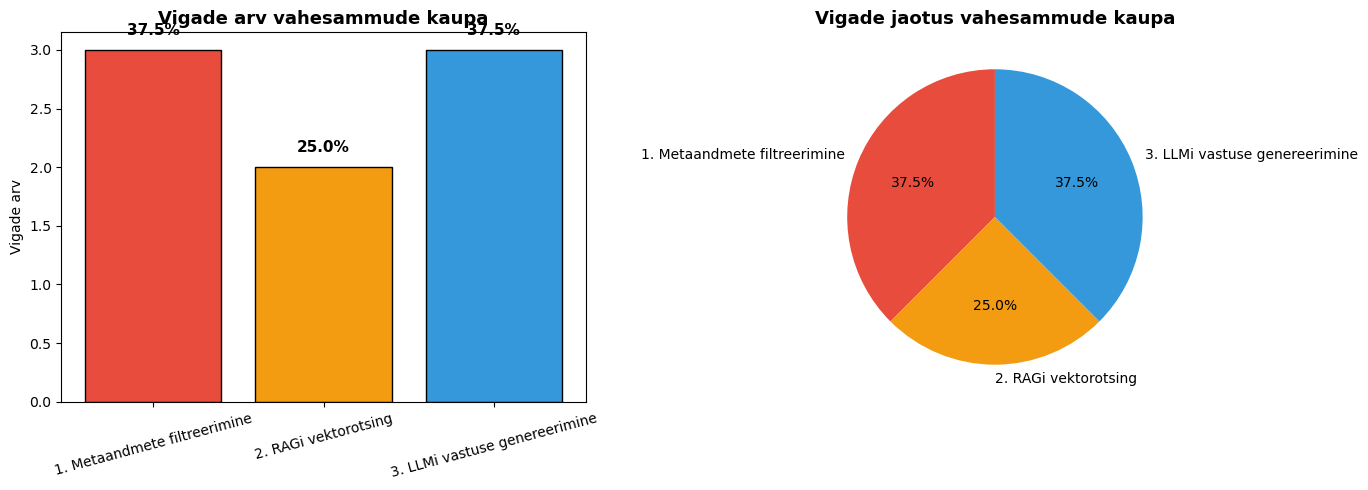

📁 Diagramm salvestatud: vigade_analuus.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Tulpdiagramm ---
bars = axes[0].bar(
    error_counts["Vahesamm"], 
    error_counts["Vigade arv"], 
    color=["#e74c3c", "#f39c12", "#3498db"],
    edgecolor="black"
)
# Lisa protsendisilte
for bar, pct in zip(bars, error_counts["Protsent vigadest (%)"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.1, 
        f"{pct}%", 
        ha="center", va="bottom", fontweight="bold", fontsize=11
    )
axes[0].set_title("Vigade arv vahesammude kaupa", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Vigade arv")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=15)

# --- Sektordiagramm ---
axes[1].pie(
    error_counts["Vigade arv"], 
    labels=error_counts["Vahesamm"], 
    autopct="%1.1f%%", 
    colors=["#e74c3c", "#f39c12", "#3498db"],
    startangle=90,
    textprops={"fontsize": 10}
)
axes[1].set_title("Vigade jaotus vahesammude kaupa", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("vigade_analuus.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Diagramm salvestatud: vigade_analuus.png")

## 6. Kokkuvõte

### Katsetuste ülevaade

Katsetasime AI Kursuse Nõustaja rakendust **20 erineva päringuga**, mis hõlmasid erinevaid teemasid (andmeteadus, programmeerimine, filosoofia, meditsiin, keeled jne) ning erinevaid filtrikombinatsioone (semester, linn, õppeaste, EAP, hindamisviis, õppevorm).

| Näitaja | Väärtus |
|---|---|
| Katsetusi kokku | 20 |
| Head tulemused (👍) | 12 (60,0%) |
| Halvad tulemused (👎) | 8 (40,0%) |

### Vigade jaotus vahesammude kaupa

| Vahesamm | Vigade arv | Protsent vigadest |
|---|---|---|
| 1. Metaandmete filtreerimine | 3 | 37,5% |
| 2. RAGi vektorotsing | 2 | 25,0% |
| 3. LLMi vastuse genereerimine | 3 | 37,5% |

### Peamised järeldused

- **Metaandmete filtreerimine (37,5% vigadest)** — vead tekivad peamiselt juhul, kui kasutaja valib liiga kitsaid filtrite kombinatsioone (nt „doktoriõpe + Pärnu + sügissemester" või „magistriõpe + Tallinn + andmekaevandus"), millele andmestikus lihtsalt ei leidugi vasteid. Lahendus: rakenduses võiks kuvada kasutajale hoiatust kui filtreeritud tulemuste arv langeb nulli lähedale, ja soovitada filtreid laiendada.

- **RAGi vektorotsing (25,0% vigadest)** — vektorotsing leidis sisuliselt valed kursused, mis ei vastanud kasutaja tegelikule vajadusele. See juhtub, kui päring on liiga üldine, nišiteema kohta puuduvad andmestikus täpsed vasted, või kui semantiline sarnasus ei peegelda sisulist sobivust. Lahendus: embedding-mudeli peenhäälestamine või hübriidotsing (vektor + märksõna) parandaks tulemusi.

- **LLMi vastuse genereerimine (37,5% vigadest)** — keelimudel lisas infot, mida otsingutulemused ei sisaldanud (hallutsinatsioon), või tõlgendas konteksti valesti. Näiteks väitis, et Robootika kursus katab droonide teemat, kuigi seda kontekstis ei olnud, või mainis neuroteadust psühholoogia kursuste juures ilma aluseta. Lahendus: süsteemiviipa karmistamine ja konkreetsemad juhised hallutsinatsioonide vältimiseks.

### Lõppjäreldus

Vigade jaotus on suhteliselt ühtlane kõigi kolme vahesammu vahel, mis näitab, et süsteemi parandamiseks on vaja tegeleda kõigi komponentidega. Vahesammude logimine ja „kapoti alla" vaade on äärmiselt kasulikud, sest võimaldavad täpselt tuvastada, kus probleem tekkis, ja suunata arendustööd õigesse kohta.

## 7. Testjuhtumid (oodatavate tulemustega)

Allpool on 17 testjuhtumit, kus iga päringu puhul on toodud **oodatavad aine koodid** (`unique_ID`), mis peavad RAG-otsingu Top 5 tulemuste seas olema. Need testjuhtumid võimaldavad automaatselt kontrollida, kas süsteem leiab õiged ained. Kõik kursusekoodid on kontrollitud ÕIS2 API kaudu ja on **kinnitatud** staatusega.

In [ ]:
# Testjuhtumid: päring + oodatavad unique_ID-d, mis peavad Top 5 seas olema
test_cases = [
    # --- Esimesed 7 testjuhtumit ---
    {
        "päring": "Soovin õppida masinõpet",
        "oodatavad_id": ["MTAT.03.227", "LTAT.02.004"],
        "selgitus": "Masinõpe (sügis) ja Masinõpe II (kevad) peavad olema tulemuste seas"
    },
    {
        "päring": "Otsin programmeerimise kursusi algajatele",
        "oodatavad_id": ["LTAT.03.001", "MTAT.03.256"],
        "selgitus": "Programmeerimine ja Programmeerimise alused II peavad leiduma"
    },
    {
        "päring": "Millised andmebaasidega seotud ained on saadaval?",
        "oodatavad_id": ["LTAT.03.004", "MTAT.03.105"],
        "selgitus": "Andmebaasid ja Sissejuhatus andmebaasidesse peavad olema tulemuste seas"
    },
    {
        "päring": "Tahan õppida tehisintellekti",
        "oodatavad_id": ["LTAT.01.003"],
        "selgitus": "Tehisintellekt (6 EAP) peab kindlasti tulemuste seas olema"
    },
    {
        "päring": "Soovitan mulle filosoofia aineid",
        "oodatavad_id": ["FLFI.00.001", "FLFI.01.103"],
        "selgitus": "Sissejuhatus filosoofiasse ja Filosoofia ajalugu I peavad leiduma"
    },
    {
        "päring": "Otsin robootika kursust",
        "oodatavad_id": ["LOTI.05.032", "LOTI.05.057"],
        "selgitus": "Robootika projekt ja Robotitehnoloogia peavad tulemuste seas olema"
    },
    {
        "päring": "Soovin õppida Pythonis programmeerimist",
        "oodatavad_id": ["HVEE.04.028", "HVEE.04.004"],
        "selgitus": "Programmeerimine Pythonis tekstiandmetega ja Eesti keele töötlus Pythonis"
    },
    # --- 10 uut testjuhtumit ---
    {
        "päring": "Soovin õppida statistikat",
        "oodatavad_id": ["MTMS.02.059", "MTMS.01.035"],
        "selgitus": "Tõenäosusteooria ja matemaatiline statistika ning Matemaatiline statistika II"
    },
    {
        "päring": "Otsin psühholoogia aineid",
        "oodatavad_id": ["P2VK.09.006", "P2NC.00.085"],
        "selgitus": "Isiksuse- ja sotsiaalpsühholoogia ning Suhtlemispsühholoogia peavad leiduma"
    },
    {
        "päring": "Tahan õppida eetikat",
        "oodatavad_id": ["FLFI.02.138"],
        "selgitus": "Õpetaja eetika ja väärtuskasvatus peab tulemuste seas olema"
    },
    {
        "päring": "Millised matemaatika kursused on olemas?",
        "oodatavad_id": ["LTMS.00.003", "LTMS.00.019"],
        "selgitus": "Kõrgem matemaatika ja Diskreetne matemaatika I peavad leiduma"
    },
    {
        "päring": "Soovin õppida veebirakenduste loomist",
        "oodatavad_id": ["LTAT.05.004"],
        "selgitus": "Veebirakenduste loomine (arvutiteaduse inst.) peab tulemuste seas olema"
    },
    {
        "päring": "Otsin operatsioonisüsteemide kursust",
        "oodatavad_id": ["LTAT.06.001"],
        "selgitus": "Operatsioonisüsteemid (6 EAP) peab kindlasti tulemuste seas olema"
    },
    {
        "päring": "Soovin õppida andmeteadust ja andmeanalüüsi",
        "oodatavad_id": ["LTAT.06.014", "MTMS.01.100"],
        "selgitus": "Linnaliikluse andmeteadus ja Statistiline andmeteadus ja visualiseerimine"
    },
    {
        "päring": "Tahan õppida orgaanilist keemiat",
        "oodatavad_id": ["LOKT.09.004"],
        "selgitus": "Orgaaniline keemia I peab tulemuste seas olema"
    },
    {
        "päring": "Otsin Eesti ajaloo aineid",
        "oodatavad_id": ["FLAJ.03.168"],
        "selgitus": "Eesti lähiajalugu peab tulemuste seas olema"
    },
    {
        "päring": "Soovin õppida inglise keelt",
        "oodatavad_id": ["HVLC.01.040"],
        "selgitus": "Inglise keel kõrgtasemele (100% e-õpe) peab tulemuste seas olema"
    },
]

# Kuvame testjuhtumid tabelina
test_df = pd.DataFrame([
    {
        "Nr": i+1,
        "Päring": tc["päring"],
        "Oodatavad ID-d": ", ".join(tc["oodatavad_id"]),
        "Selgitus": tc["selgitus"]
    }
    for i, tc in enumerate(test_cases)
])
test_df

,Nr,Päring,Oodatavad ID-d,Selgitus
0,1,Soovin õppida masinõpet,"MTAT.03.227, LTAT.02.004",Masinõpe (sügis) ja Masinõpe II (kevad) peavad...
1,2,Otsin programmeerimise kursusi algajatele,"LTAT.03.001, MTAT.03.256",Programmeerimine ja Programmeerimise alused II...
2,3,Millised andmebaasidega seotud ained on saadaval?,"LTAT.03.004, MTAT.03.105",Andmebaasid ja Sissejuhatus andmebaasidesse pe...
3,4,Tahan õppida tehisintellekti,LTAT.01.003,Tehisintellekt (6 EAP) peab kindlasti tulemust...
4,5,Soovitan mulle filosoofia aineid,"FLFI.00.001, FLFI.01.103",Sissejuhatus filosoofiasse ja Filosoofia ajalu...
5,6,Otsin robootika kursust,"LOTI.05.032, LOTI.05.057",Robootika projekt ja Robotitehnoloogia peavad ...
6,7,Soovin õppida Pythonis programmeerimist,"HVEE.04.028, HVEE.04.004",Programmeerimine Pythonis tekstiandmetega ja E...
7,8,Soovin õppida statistikat,"MTMS.02.059, MTMS.01.035",Tõenäosusteooria ja matemaatiline statistika n...
8,9,Otsin psühholoogia aineid,"P2VK.09.006, P2NC.00.085",Isiksuse- ja sotsiaalpsühholoogia ning Suhtlem...
9,10,Tahan õppida eetikat,FLFI.02.138,Õpetaja eetika ja väärtuskasvatus peab tulemus...
